---
title: 'Deep Learning for Coder: Chapter 5'
slug: deep-learning-for-coder-chapter-5
date: '2025-09-16'
draft: false
toc: true
categories:
  - book notes
tags:
  - machine learning
  - deep learning
  - python
jupyter: python3
sitemap:
    changefreq: never
    priority: 1.0
---

In [ ]:
import fastbook
fastbook.setup_book()

In [ ]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)

In [ ]:
path.ls()

(#2) [Path('/root/.fastai/data/oxford-iiit-pet/annotations'),Path('/root/.fastai/data/oxford-iiit-pet/images')]

In [ ]:
pets = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(seed=42),
    get_y=using_attr(RegexLabeller(r"(.+)_\d+.jpg$"), "name"),
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(size=224, min_scale=0.75),
)
dls = pets.dataloaders(path/"images")

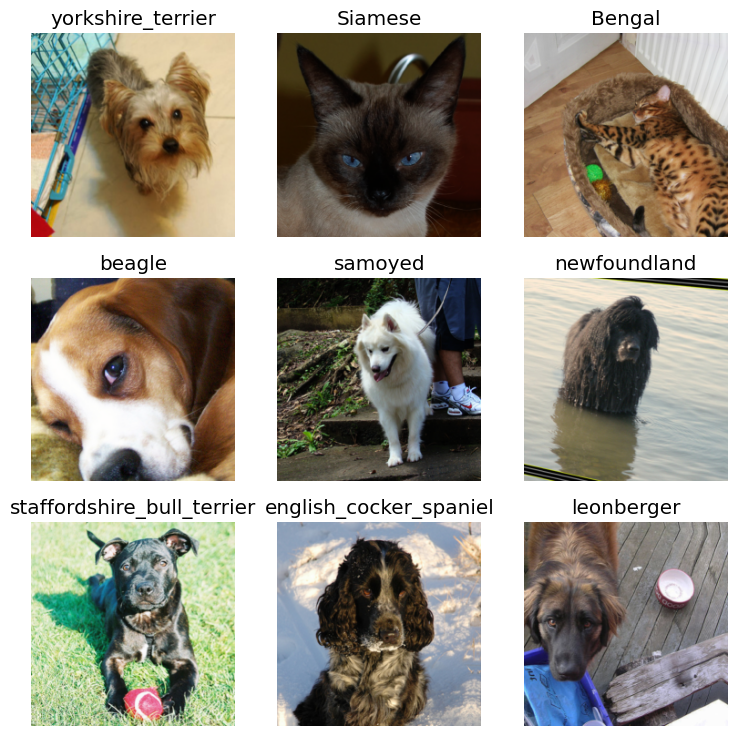

In [ ]:
dls.show_batch(nrows=3, ncols=3)

In [ ]:
learn = cnn_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 108MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.497884,0.302666,0.087280,01:02


epoch,train_loss,valid_loss,error_rate,time
0,0.494630,0.309310,0.099459,01:04
1,0.310687,0.254076,0.084574,01:06


In [ ]:
x, y = dls.one_batch()

In [ ]:
preds, _ = learn.get_preds(dl = [(x,y)])
torch.argmax(preds[0])

tensor(10)

In [ ]:
acts = torch.randn((6,2))*2
acts

tensor([[ 0.2126, -0.6733],
        [ 0.5868,  1.8977],
        [-1.5544,  0.4964],
        [-0.5226, -0.6044],
        [ 0.4885, -0.1626],
        [-3.0538, -2.0372]])

In [ ]:
acts.sigmoid().sum(1).unsqueeze(1)

tensor([[0.8907],
        [1.5123],
        [0.7961],
        [0.7256],
        [1.0792],
        [0.1604]])

In [ ]:
(acts[:,0]-acts[:,1]).sigmoid().unsqueeze(1)

tensor([[0.7080],
        [0.2123],
        [0.1140],
        [0.5204],
        [0.6573],
        [0.2657]])

In [ ]:
def softmax(x): return torch.exp(x) / torch.exp(x).sum(dim=1, keepdim=True)
sm_acts = softmax(acts)

In [ ]:
sm_acts

tensor([[0.7080, 0.2920],
        [0.2123, 0.7877],
        [0.1140, 0.8860],
        [0.5204, 0.4796],
        [0.6573, 0.3427],
        [0.2657, 0.7343]])

In [ ]:
targ = tensor([0,1,0,0,1,1])
sm_acts[range(6),targ].unsqueeze(1)

tensor([[0.7080],
        [0.7877],
        [0.1140],
        [0.5204],
        [0.3427],
        [0.7343]])

In [ ]:
-sm_acts[range(6),targ].log().mean()

tensor(0.7981)

In [ ]:
F.nll_loss(acts.log_softmax(dim=1), targ)

tensor(0.7981)

In [ ]:
loss_func = nn.CrossEntropyLoss(reduction='none')
loss_func(acts, targ)

tensor([0.3452, 0.2387, 2.1718, 0.6531, 1.0708, 0.3088])

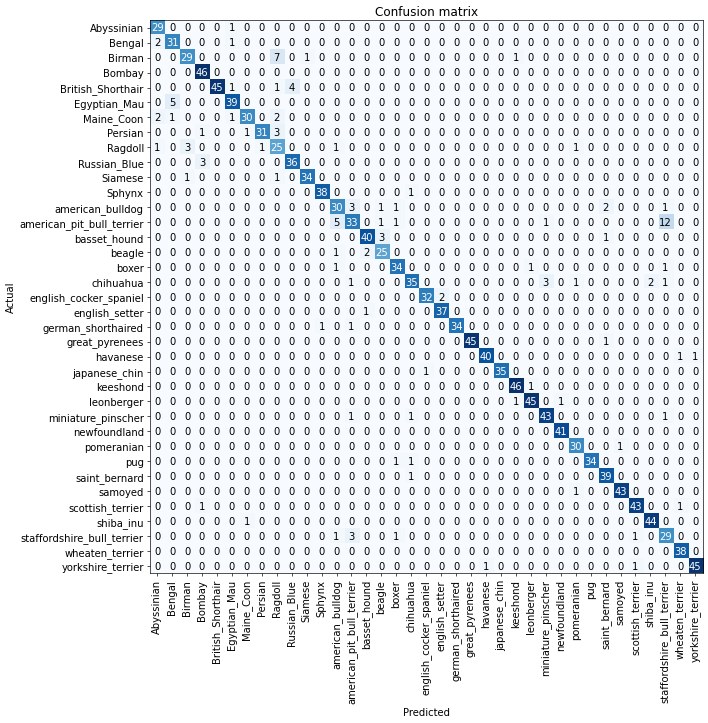

In [ ]:
interp  = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(12,12), dpi=60)

In [ ]:
interp.most_confused(min_val=5)

[('american_pit_bull_terrier', 'staffordshire_bull_terrier', np.int64(12)),
 ('Birman', 'Ragdoll', np.int64(7)),
 ('Egyptian_Mau', 'Bengal', np.int64(5)),
 ('american_pit_bull_terrier', 'american_bulldog', np.int64(5))]

SuggestedLRs(valley=0.001737800776027143)

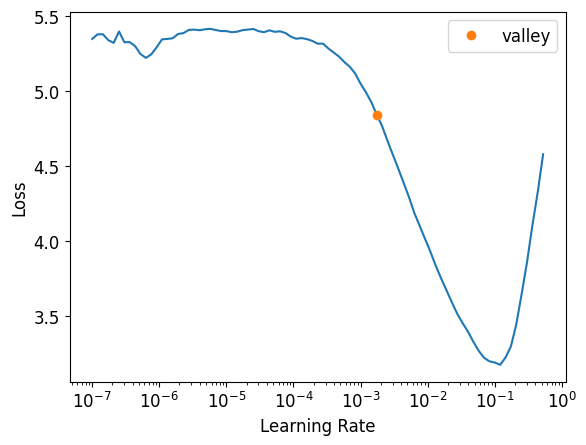

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.lr_find()

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2, base_lr=3e-3)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


epoch,train_loss,valid_loss,error_rate,time
0,1.330929,0.305042,0.089986,01:07


epoch,train_loss,valid_loss,error_rate,time
0,0.523440,0.362486,0.104871,01:10
1,0.327184,0.269103,0.080514,01:06


In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, 3e-2)

epoch,train_loss,valid_loss,error_rate,time
0,2.357152,3.695568,0.578484,00:12
1,1.188880,0.541915,0.169824,00:11
2,0.660204,0.358833,0.108931,00:11


In [ ]:
learn.unfreeze()

SuggestedLRs(valley=3.630780702224001e-05)

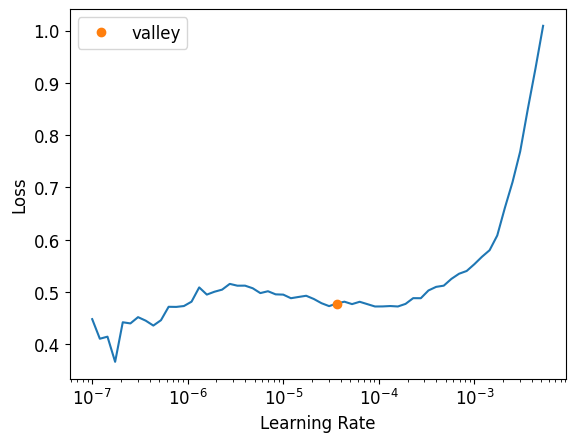

In [ ]:
learn.lr_find()

In [ ]:
learn.fit_one_cycle(6,  lr_max=1e-6)

epoch,train_loss,valid_loss,error_rate,time
0,0.474540,0.356742,0.108931,00:12
1,0.472879,0.353283,0.110284,00:12
2,0.471576,0.347057,0.103518,00:12
3,0.464339,0.345362,0.100812,00:12
4,0.468930,0.342762,0.106225,00:12
5,0.452638,0.343595,0.103518,00:12


In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, 3e-3)
learn.unfreeze()
learn.fit_one_cycle(12, lr_max=slice(1e-6, 1e-4))

epoch,train_loss,valid_loss,error_rate,time
0,1.127102,0.334892,0.097429,00:11
1,0.518909,0.252394,0.085927,00:11
2,0.327980,0.218656,0.075778,00:11


epoch,train_loss,valid_loss,error_rate,time
0,0.243455,0.213250,0.074425,00:12
1,0.233122,0.212131,0.073748,00:12
2,0.220011,0.202811,0.063599,00:12
3,0.220371,0.196318,0.062923,00:12
4,0.191108,0.200352,0.064953,00:12
5,0.166688,0.201582,0.066982,00:12
6,0.155857,0.196664,0.062923,00:12
7,0.138741,0.190374,0.060217,00:12
8,0.118107,0.192674,0.067659,00:12
9,0.130965,0.191735,0.065629,00:12


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

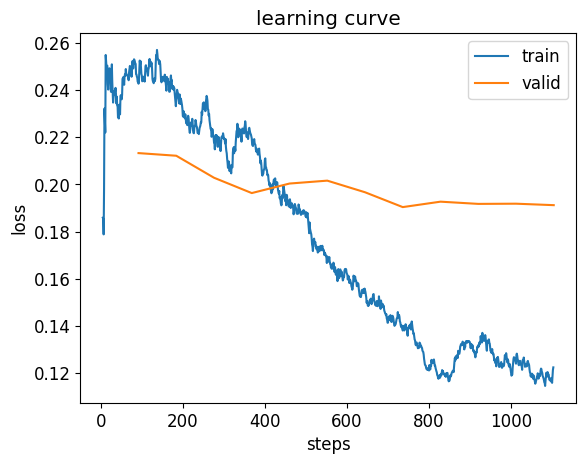

In [ ]:
learn.recorder.plot_loss()

In [ ]:
from fastai.callback.fp16 import *
learn =  vision_learner(dls, resnet50, metrics=error_rate).to_fp16()
learn.fine_tune(6, freeze_epochs=3)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


epoch,train_loss,valid_loss,error_rate,time
0,2.191112,0.475555,0.154263,00:14
1,0.829924,0.294044,0.100812,00:13
2,0.550020,0.291130,0.096752,00:13


epoch,train_loss,valid_loss,error_rate,time
0,0.305628,0.236669,0.073748,00:14
1,0.242062,0.278092,0.081867,00:14
2,0.209351,0.231892,0.069689,00:14
3,0.133353,0.220406,0.064276,00:14
4,0.089182,0.202463,0.050744,00:14
5,0.065977,0.192152,0.052774,00:14
